

# Big Ideas Graphical
### OPIM 5641 - Business Decision Modeling · Module2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/4_Graphical/BigIdeas_Graphical.ipynb)

*Run me top to bottom - **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Big Ideas: Graphical Method
--------------------------------
**Dr. Dave Wanik - OPIM 5641: Business Decision Modeling - University of Connecticut**

If you have two decision variables in your linear programming model, you can leverage the graphical method to easily communicate how constraints impact your business operations.


The big ideas here are that:
* When there are only two decision variables, it is possible to create a visualization of the linear programming model
  * Each decision variable becomes an axis (instead of X or Y, we may have 'Tables' and 'Chairs'. The choice of which variable is on the horizontal or vertical axis is up to you.)
* Constraints are lines on a 2D plane. Given the $\leq$ and $\geq$ inequalities, one side of the line is feasible and the other side is infeasible (i.e. the constraint is violated)
* Corner points are formed at the interesections of two constraints, or of a single constrant with an axis (X or Y).
* Constraints help form a 'feasible region' where a solution space exists.
* Rather than exploring all values within the solution space, we focus exclusively on corner points. This substantially cuts down on computing time (e.g. evaluating five corner points takes much less time than computing all possible combinations of values with brute-force method)
* On the plus side, if your problem only has two decision variables, you can easily communicate information about constraints and how this can constrict the feasible region
* On the down side, this only works for 2D - if you have more than two decision variables, you must rely upon other methods (such as the Simplex method).
  

<center>

![LP example with graphical method](https://analyticsindiamag.com/wp-content/uploads/2019/06/Screenshot_2019-06-17-Chapter-12-Linear-Programming-pmd-lemh206-pdf.png)

</center>

**Figure:** an example of how constraints can be pictured as lines on a 2D plane, and the subsequent feasible region (blue) that is created). Corner points are labeled by the letters A, B and C and the origin is also denoted by the letter O.

In our class, you will need to figure out how to draw these by hand and with code.

In [1]:
from pylab import *

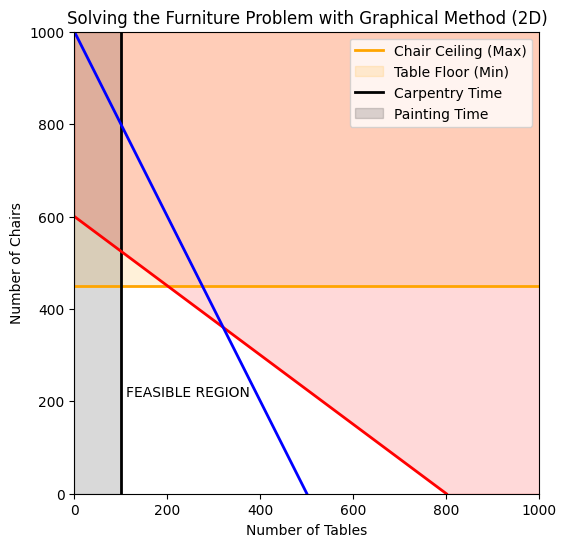

In [2]:
figure(figsize=(6,6)) # this makes the image nice and big! try 5,5 or 10,10 if you want
axis([0,1000,0,1000]) # these are the limits for x and y (xmin, xmax, ymin, ymax). try xmin= 10 and xmax = 500 while ymin=0 and ymax=1000
xlabel('Number of Tables') # ALWAYS add pretty titles (xlabel, which we've decided to be tables)
ylabel('Number of Chairs') # ALWAYS add pretty titles (ylabel, which we've decided to be chairs)

# Max Chairs Constraint (horizontal line)
x = array([0, 1000])
y = array([450, 450])
plot(x, y,'orange',lw=2) # the lw=2 argument makes a line
fill_between(x=[0, 1000], # x area
             y1=[450, 450], # y1 area (lower end of curve) - shade above here!
             y2=[1000, 1000], # y2 area (upper end of curve) - shade below here!
             color='orange', # color
             alpha=0.15) # transparency

# Min Tables Constraint (vertical line)
x = array([100, 100])
y = array([0, 1000])
plot(x, y,'black',lw=2)
fill_between(x=[0,100],
             y1=[0,0],
             y2=[1000,1000],
             color='black',
             alpha=0.15)

# Carpentry Time
# remember, T is x and C is y... be consistent or you are toast!
x = array([0, 800]) # tables
y = array([600, 0]) # chairs
plot(x, y,'red',lw=2)

# this the right way with three arguments to x, y1 and y2
fill_between(x=[0,800, 1000], # tables
             y1=[600,0,0],
             y2=[1000,1000,1000],
             color='red',
             alpha=0.15)

# Paiting Time
# remember, T is x and C is y... be consistent or you are toast!
x = array([0, 500]) # tables
y = array([1000, 0]) # chairs
plot(x, y,'blue',lw=2)

# this the right way with three arguments to x, y1 and y2
fill_between(x=[0,500, 1000], # tables
             y1=[1000,0,0],
             #y2=[1000,1000,1000],
             y2=[Inf, Inf, Inf],
             color='blue',
             alpha=0.15)

# bells and whistles
title('Solving the Furniture Problem with Graphical Method (2D)')
text(x=110,y=210,s='FEASIBLE REGION')
# don't forget to use square brackets [] to hold all of your legend items
legend(['Chair Ceiling (Max)',
       'Table Floor (Min)',
       'Carpentry Time',
       'Painting Time'])
show() # put this at the end, otherwise you will make two plots!

Of course, you are going to need some new skills plotting items related to the graphical method.


## Drawing a constraint
It's easy enough to draw a single line like this:

`x = array([0, 800]) # tables
y = array([600, 0]) # chairs
plot(x, y,'red',lw=2)`

You have to know your start and end points (where the constraint cross the axes, but once you do, making a line on the plot is pretty straightforward.

## Shading the infeasible region
This is where students have a little bit of trouble. We'll use the most difficult example to show how to do this.

`# this the right way with three arguments to x, y1 and y2`

`fill_between(x=[0,800, 1000], # tables`
`             y1=[600,0,0],`
`             y2=[1000,1000,1000],`
`             color='red',`
`             alpha=0.15)`

`color` is the color (red, green, blue, orange, black etc.) and `alpha` is the percentage transparent (0 is completely transparent, 0.5 is half transparent, and 1 is solid)

`fill_between` requires a little bit of nuance. 🔶 This is where most students have trouble. Here's how I like to think of it: imagine you are shading between two curves - they both have the same X values, but they will have different Y values. y1 is the bottom curve, and y2 is the top curve.

In this example, y1 is the bottom curve and y2 could have been `[Inf, Inf, Inf]` instead of the values of [1000, 1000, 1000]... both work well!

# OK I have a cool graph, now what?

## Find the corner points
Think of these as the most extreme areas of the feasible region. These are the points where you should focus all of your attention.

Some corner points are easy to identify (like those that intercept an axis).

Other corner points are tricky (like those where two constraints intersect). When this happens, line both of the constraints up and add (or subtract) them to solve for one variable, then plug it back in and solve for the other variable.

## Evaluate!
This is the easy part - once all of your corner points are identified, simply put the values into the objective function and select the one that improves (maximizes OR minimizes) the objective function the most.

# Other ideas...
What if you have more than 2 decision variables? You will need to use another method - the Simplex algorithm - to solve your problem. It is an algebraic extension of the geometric-driven graphical method.